In [ ]:
# Install gwexpy with pinned versions of core dependencies for reproducibility on Colab

%pip install -q "gwexpy[all]" "gwpy<5.0.0" "numpy<2.0.0" "scipy<1.13.0" "astropy<7.0.0"

# SegmentTable 入門

**目的**: `SegmentTable` を使用して時刻キー付きデータ解析を管理する方法を学びます。

`SegmentTable` は、特定の時間セグメントに関連付けられたメタデータとペイロードデータ（TimeSeries や PSD など）のコンテナです。大規模なデータセットを効率的に扱うため、遅延読み込みをサポートしています。

## 1. SegmentTable の作成

GPS 開始・終了時刻を持つセグメントを定義した CSV ファイルからサンプルデータを読み込みます。

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

from gwexpy.table import SegmentTable
import os

# tutorials ディレクトリから _static/samples/ への相対パス
# Try to find CSV file by searching up the directory tree
import os
csv_candidates = [
    "../../../../_static/samples/sample_segment_data.csv",
    "../../../../../_static/samples/sample_segment_data.csv",
    "../../_static/samples/sample_segment_data.csv",
]
sample_csv = None
for candidate in csv_candidates:
    abspath = os.path.abspath(candidate)
    if os.path.exists(abspath):
        sample_csv = abspath
        break
if sample_csv is None:
    raise FileNotFoundError(f"Could not find sample_segment_data.csv. Tried: {csv_candidates}")
st = SegmentTable.read(sample_csv)

print(st)
st.display().head()

   start  end label          span
0      0    4     A    (0.0, 4.0)
1      4    8     B    (4.0, 8.0)
2     10   13     C  (10.0, 13.0)
3     15   20     D  (15.0, 20.0)
4     22   25     E  (22.0, 25.0)


,start,end,label,span
0,0,4,A,"(0.0, 4.0)"
1,4,8,B,"(4.0, 8.0)"
2,10,13,C,"(10.0, 13.0)"
3,15,20,D,"(15.0, 20.0)"
4,22,25,E,"(22.0, 25.0)"


## 2. セグメントの可視化

セグメントのタイムラインを素早く可視化できます。

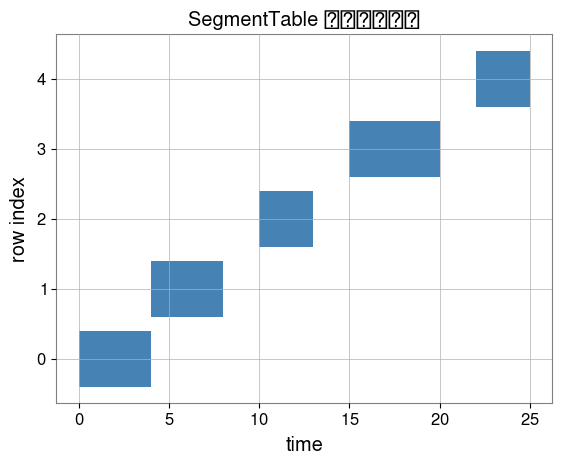

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
st.segments(ax=ax, label="チュートリアルセグメント")
plt.title("SegmentTable タイムライン")
plt.show()

## 3. ペイロードの遅延読み込み

`SegmentTable` ではカラムに「ローダー」を紐付けることができます。データは実際にアクセスされたときのみ読み込まれます。

In [3]:
from gwexpy.noise.wave import gaussian

def noise_loader(segment):
    # セグメント用の合成ノイズを生成
    duration = float(segment[1] - segment[0])
    return gaussian(duration=duration, sample_rate=1024, t0=float(segment[0]))

# 注意: 遅延読み込み可能なペイロードデータには add_series_column を使用（kind='timeseries' など）
st.add_series_column("noise", loader=noise_loader, kind="timeseries")

# 最初の行のノイズにアクセス（読み込みが実行される）
data_0 = st.row(0)["noise"]
print(f"GPS {data_0.t0.value} から {len(data_0)} サンプルを読み込みました")

GPS 0.0 から 4096 サンプルを読み込みました


## 4. 行ごとの処理

行をイテレートしたり、`apply` を使ってデータを処理したりできます。

In [4]:
# 各ノイズセグメントの RMS を計算
# 軽量なメタデータ結果には add_column を使用
st.add_column("rms", data=[row["noise"].rms().value for row in st])
st.display()

,start,end,label,span,rms,noise
0,0,4,A,"(0.0, 4.0)",1.007360,<timeseries: 4096 samples>
1,4,8,B,"(4.0, 8.0)",0.991072,<timeseries: 4096 samples>
2,10,13,C,"(10.0, 13.0)",0.995339,<timeseries: 3072 samples>
3,15,20,D,"(15.0, 20.0)",0.989703,<timeseries: 5120 samples>
4,22,25,E,"(22.0, 25.0)",0.982969,<timeseries: 3072 samples>


## 5. 検証セル（NBMAKE）

In [5]:
assert "noise" in st.columns
assert len(st) > 0
print("検証完了！")

検証完了！
